<a href="https://colab.research.google.com/github/HonestyDisciplineConsistency/CSCI323-Group-Project/blob/main/CSCI323_Group_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import required libraries

These libraries are used for loading data, preprocessing text, training the models, tuning hyperparameters, and evaluating results.

In [33]:
# Basic libraries
import re
import warnings
import zipfile
import urllib.request
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Display helper for notebooks
from IPython.display import display

# Machine learning tools
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


### Explanation
This cell imports all tools needed for the experiment. pandas handles the dataset, re cleans text, matplotlib creates charts, and scikit-learn provides TF-IDF, model training, tuning, and evaluation functions.

## 2. Set random seed

A fixed random seed is used so that the train-test split and model results are reproducible.

In [34]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Random seed set to:", RANDOM_STATE)

Random seed set to: 42


### Explanation
The random seed keeps the train-test split and model results reproducible. The outputs folder stores generated charts and result CSV files for the report.

## 3. Load the UCI SMS Spam Collection Dataset

This notebook loads the UCI SMS Spam Collection dataset in a reliable way.

It checks for a local CSV file using the filename uci_sms_spam_collection.csv

If file is not found, the notebook automatically downloads the original UCI zipped dataset and loads it directly. This prevents FileNotFoundError when running in Google Colab or Jupyter.

In [35]:
def read_csv_safely(file_path):
    """Read a CSV file using common encodings."""
    encodings = ["utf-8", "latin-1", "ISO-8859-1", "cp1252"]

    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue

    return pd.read_csv(file_path, encoding="latin-1")


def load_uci_sms_dataset():
    """
    Load the UCI SMS Spam Collection dataset.

    Priority:
    1. Load local uci_sms_spam_collection.csv if it exists.
    2. Load local sms.csv if it exists.
    3. If neither exists, download the original UCI dataset automatically.
    """
    possible_file = [
        "uci_sms_spam_collection.csv",
    ]

    for filename in possible_file:
        file_path = Path(filename)
        if file_path.exists():
            print(f"Loaded local dataset: {filename}")
            df = read_csv_safely(file_path)

            # If the file already has correct columns, return them.
            if {"label", "message"}.issubset(df.columns):
                return df[["label", "message"]].copy()

            # If it came from the original SMS collection format, handle two unnamed columns.
            if df.shape[1] >= 2:
                df = df.iloc[:, :2].copy()
                df.columns = ["label", "message"]
                return df

            raise ValueError(f"Could not identify label/message columns in {filename}. Found columns: {list(df.columns)}")

    print("No local CSV found. Downloading the original UCI SMS Spam Collection dataset...")

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
    zip_path = Path("smsspamcollection.zip")

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        with zip_ref.open("SMSSpamCollection") as file:
            df_uci = pd.read_csv(
                file,
                sep="\t",
                header=None,
                names=["label", "message"]
            )

    print("Downloaded and loaded UCI SMS Spam Collection dataset.")
    return df_uci


raw_df = load_uci_sms_dataset()

print("Dataset shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns:")
print(list(raw_df.columns))
print("\nLabel counts:")
print(raw_df["label"].value_counts())

Loaded local dataset: uci_sms_spam_collection.csv
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Columns:
['label', 'message']

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


### Explanation
This cell loads the UCI SMS Spam Collection dataset. It first checks whether uci_sms_spam_collection.csv exists locally; if not, it downloads the dataset automatically from UCI. The final dataset contains two columns: label and message.

## 4. Check label distribution

This step checks whether the dataset is balanced or imbalanced.

label
ham     4825
spam     747
Name: count, dtype: int64


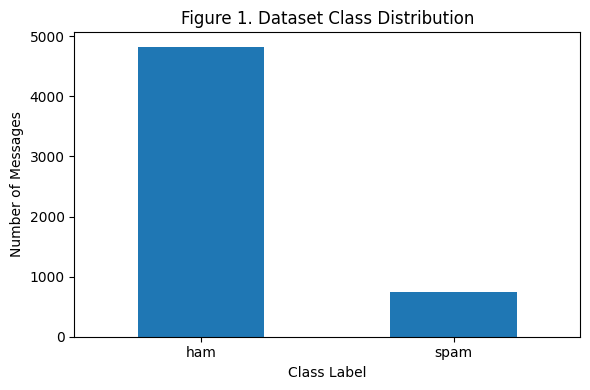

In [36]:
label_counts = raw_df["label"].value_counts()
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Figure 1. Dataset Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_1_class_distribution.png", dpi=300)
plt.show()

### Explanation
This chart checks the number of ham and spam messages. The dataset is imbalanced because ham messages appear more often than spam messages, so later evaluation uses precision, recall, F1-score, ROC-AUC, and confusion matrices instead of accuracy alone.

## 5. Clean labels and text

The labels are converted into numbers:

- ham = 0
- spam = 1

The message text is also cleaned by lowercasing, removing URLs, removing email addresses, removing punctuation/symbols, and removing extra spaces.

In [37]:
def clean_text(text):
    """Clean raw message text for spam classification."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)             # remove email addresses
    text = re.sub(r"[^a-zA-Z\s]", " ", text)         # keep letters and spaces only
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text


df = raw_df.copy()
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df["clean_message"] = df["message"].apply(clean_text)

# Remove any rows with invalid labels, if any
df = df.dropna(subset=["label_num"]).copy()
df["label_num"] = df["label_num"].astype(int)

print("Cleaned dataset shape:", df.shape)
print("\nLabel counts after cleaning:")
print(df["label_num"].value_counts())

display(df[["label", "label_num", "message", "clean_message"]].head())

Cleaned dataset shape: (5572, 4)

Label counts after cleaning:
label_num
0    4825
1     747
Name: count, dtype: int64


,label,label_num,message,clean_message
0,ham,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


### Explanation
This cell prepares the data for machine learning. It converts labels into numbers (ham = 0, spam = 1) and cleans each message by lowercasing text, removing URLs, email addresses, symbols, and extra spaces. This reduces noise before TF-IDF feature extraction.

## 6. Train-test split

The dataset is split into:

- 80% training data
- 20% testing data

stratify=y is used to preserve the spam/ham ratio in both sets.

In [38]:
X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4457
Testing set size: 1115

Training label distribution:
label_num
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Testing label distribution:
label_num
0    0.866368
1    0.133632
Name: proportion, dtype: float64


### Explanation
The data is split into training and testing sets. The model learns from the training set and is evaluated on the unseen test set. Stratification keeps the spam/ham ratio similar in both sets, making the evaluation fairer.

## 7. Create model pipelines

Both models use the same TF-IDF representation so that the comparison is fair.

- **Multinomial Naive Bayes**: suitable for text classification and word-based features.
- **Decision Tree**: interpretable, but may overfit high-dimensional TF-IDF features.

In [39]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", MultinomialNB())
])

dt_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

print("Naive Bayes and Decision Tree pipelines created.")

Naive Bayes and Decision Tree pipelines created.


### Explanation
This cell builds two model pipelines. Each pipeline first applies TF-IDF to convert text into numerical features, then trains either Multinomial Naive Bayes or Decision Tree. Using the same TF-IDF step makes the comparison fair.

## 8. Hyperparameter tuning with cross-validation

GridSearchCV is used to find better model settings. The scoring metric is **F1-score** because spam detection needs a balance between precision and recall.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nb_param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__alpha": [0.1, 0.5, 1.0]
}

dt_param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [10, 20, 40],
    "model__min_samples_leaf": [1, 3]
}

nb_search = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=1  # safer for Colab/local execution
)

dt_search = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=1  # safer for Colab/local execution
)

print("Tuning Naive Bayes...")
nb_search.fit(X_train, y_train)

print("Tuning Decision Tree...")
dt_search.fit(X_train, y_train)

best_nb = nb_search.best_estimator_
best_dt = dt_search.best_estimator_

print("\nBest Naive Bayes parameters:")
print(nb_search.best_params_)
print("Best Naive Bayes CV F1:", nb_search.best_score_)

print("\nBest Decision Tree parameters:")
print(dt_search.best_params_)
print("Best Decision Tree CV F1:", dt_search.best_score_)

Tuning Naive Bayes...
Tuning Decision Tree...

Best Naive Bayes parameters:
{'model__alpha': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Best Naive Bayes CV F1: 0.9281648621953481

Best Decision Tree parameters:
{'model__criterion': 'entropy', 'model__max_depth': 40, 'model__min_samples_leaf': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Best Decision Tree CV F1: 0.8317146301509272


### Explanation
GridSearchCV tests different settings for TF-IDF and each model. The best settings are chosen using F1-score because spam detection needs a balance between catching spam and avoiding false alarms.

## 9. Evaluate models on the test set

The models are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, classification report and confusion matrix.

Naive Bayes
Accuracy     0.982063
Precision    0.977778
Recall       0.885906
F1-score     0.929577
ROC-AUC      0.988519
dtype: object

Classification Report:
              precision    recall  f1-score   support

Ham/Non-spam       0.98      1.00      0.99       966
        Spam       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



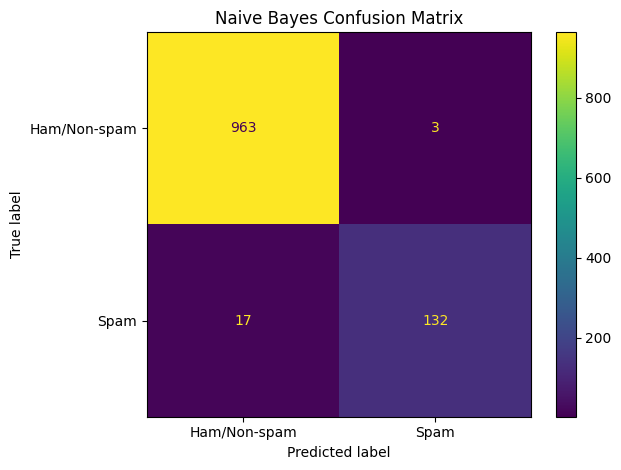

Decision Tree
Accuracy     0.948879
Precision    0.802632
Recall       0.818792
F1-score     0.810631
ROC-AUC      0.867919
dtype: object

Classification Report:
              precision    recall  f1-score   support

Ham/Non-spam       0.97      0.97      0.97       966
        Spam       0.80      0.82      0.81       149

    accuracy                           0.95      1115
   macro avg       0.89      0.89      0.89      1115
weighted avg       0.95      0.95      0.95      1115



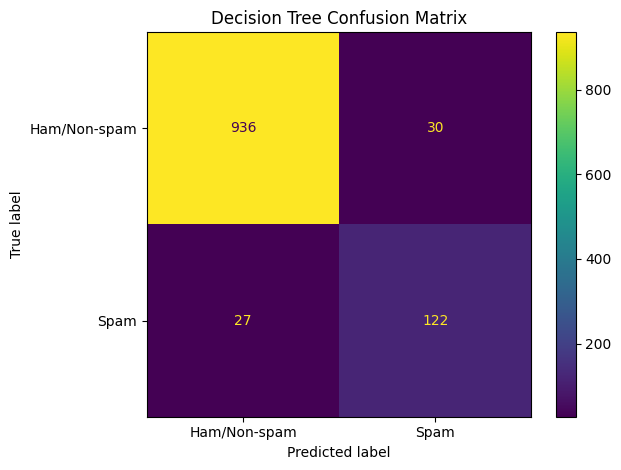

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.982063,0.977778,0.885906,0.929577,0.988519
1,Decision Tree,0.948879,0.802632,0.818792,0.810631,0.867919


In [26]:
def get_spam_probability(model, X_values):
    """Return probability for class 1 = spam."""
    probabilities = model.predict_proba(X_values)
    class_list = list(model.classes_)
    spam_index = class_list.index(1)
    return probabilities[:, spam_index]


def evaluate_model(model_name, model, X_test, y_test):
    """Evaluate a trained model and return metrics, predictions and probabilities."""
    y_pred = model.predict(X_test)
    y_proba = get_spam_probability(model, X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(pd.Series(metrics).drop("Model"))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Ham/Non-spam", "Spam"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham/Non-spam", "Spam"])
    disp.plot(values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=300)
    plt.show()

    return metrics, y_pred, y_proba


nb_metrics, nb_pred, nb_proba = evaluate_model("Naive Bayes", best_nb, X_test, y_test)
dt_metrics, dt_pred, dt_proba = evaluate_model("Decision Tree", best_dt, X_test, y_test)

results_df = pd.DataFrame([nb_metrics, dt_metrics])
display(results_df)
results_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)

### Explanation
This is the main evaluation cell. It calculates accuracy, precision, recall, F1-score, ROC-AUC, classification reports, and confusion matrices for both models. These results are used in Section 4 of the report.

## 10. Model comparison chart

This chart is used as **Figure 2** in the report.

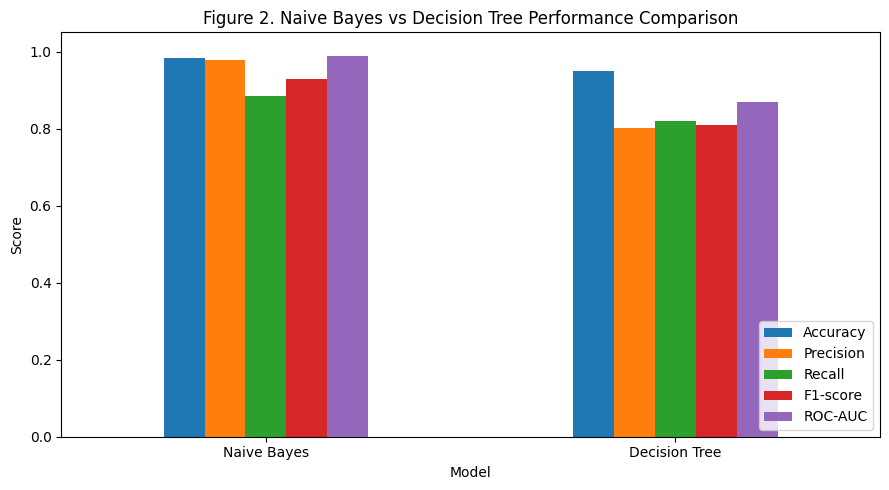

In [27]:
plot_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

ax = results_df.set_index("Model")[plot_metrics].plot(kind="bar", figsize=(9, 5))
plt.title("Figure 2. Naive Bayes vs Decision Tree Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_2_model_comparison.png", dpi=300)
plt.show()

### Explanation
This bar chart compares both models across the main metrics. It helps visually show that Naive Bayes performs better than Decision Tree in the final report.

## 11. ROC curve comparison

ROC-AUC measures how well the model separates spam from ham across different thresholds.

<Figure size 700x500 with 0 Axes>

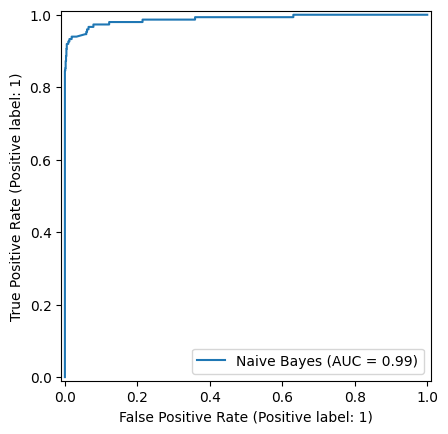

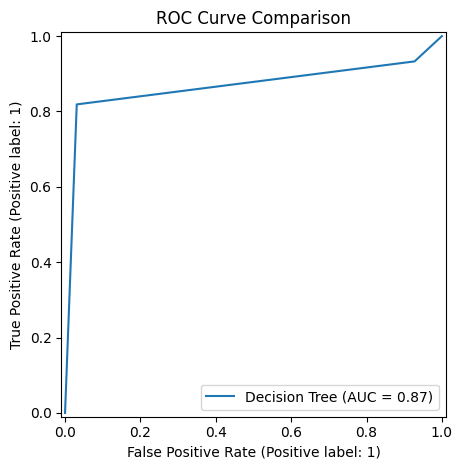

In [28]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, nb_proba, name="Naive Bayes")
RocCurveDisplay.from_predictions(y_test, dt_proba, name="Decision Tree")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_comparison.png", dpi=300)
plt.show()

### Explanation
The ROC curve shows how well each model separates spam from ham across different decision thresholds. A curve closer to the top-left and a higher ROC-AUC score indicate stronger separation ability.

## 12. Cross-validation stability

Cross-validation checks whether the model performs consistently across different data splits.

In [29]:
scoring = ["accuracy", "precision", "recall", "f1"]
cv_rows = []

for model_name, model in [("Naive Bayes", best_nb), ("Decision Tree", best_dt)]:
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Naive Bayes,0.981602,0.002314,0.974289,0.006837,0.886289,0.013529,0.928165,0.009212
1,Decision Tree,0.954009,0.007584,0.821582,0.044358,0.844482,0.031147,0.831715,0.023569


### Explanation
Cross-validation checks whether the models perform consistently across different data splits. A high mean score with a low standard deviation means the model is more stable and less dependent on one specific train-test split.

## 13. Feature interpretation

This section helps explain why the models make certain predictions.

In [30]:
def show_naive_bayes_top_words(nb_model, top_n=20):
    vectorizer = nb_model.named_steps["tfidf"]
    model = nb_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    class_list = list(model.classes_)
    ham_index = class_list.index(0)
    spam_index = class_list.index(1)

    spam_strength = model.feature_log_prob_[spam_index] - model.feature_log_prob_[ham_index]

    top_spam_indices = np.argsort(spam_strength)[-top_n:][::-1]
    top_ham_indices = np.argsort(spam_strength)[:top_n]

    top_spam = pd.DataFrame({
        "Word": feature_names[top_spam_indices],
        "Spam Association Score": spam_strength[top_spam_indices]
    })

    top_ham = pd.DataFrame({
        "Word": feature_names[top_ham_indices],
        "Ham Association Score": spam_strength[top_ham_indices]
    })

    return top_spam, top_ham


def show_decision_tree_top_features(dt_model, top_n=20):
    vectorizer = dt_model.named_steps["tfidf"]
    model = dt_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[-top_n:][::-1]

    return pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Importance": importances[top_indices]
    })


top_spam_words, top_ham_words = show_naive_bayes_top_words(best_nb, top_n=20)
dt_top_features = show_decision_tree_top_features(best_dt, top_n=20)

print("Top words associated with spam according to Naive Bayes:")
display(top_spam_words)

print("Top words associated with ham/non-spam according to Naive Bayes:")
display(top_ham_words)

print("Top Decision Tree features:")
display(dt_top_features)

top_spam_words.to_csv(OUTPUT_DIR / "naive_bayes_top_spam_words.csv", index=False)
top_ham_words.to_csv(OUTPUT_DIR / "naive_bayes_top_ham_words.csv", index=False)
dt_top_features.to_csv(OUTPUT_DIR / "decision_tree_top_features.csv", index=False)

Top words associated with spam according to Naive Bayes:


,Word,Spam Association Score
0,claim,6.252926
1,prize,6.021076
2,tone,5.511964
3,guaranteed,5.488610
4,ppm,5.485776
5,cs,5.421877
6,pobox,5.379955
7,ringtone,5.309242
8,landline,5.280263
9,awarded,5.175814


Top words associated with ham/non-spam according to Naive Bayes:


,Word,Ham Association Score
0,gt,-5.003026
1,lt,-4.985462
2,lt gt,-4.884574
3,lor,-4.753045
4,later,-4.690602
5,doing,-4.222355
6,lol,-4.167392
7,ask,-4.130898
8,sure,-4.037739
9,class,-3.996156


Top Decision Tree features:


,Feature,Importance
0,txt,0.113760
1,claim,0.086488
2,free,0.081098
3,box,0.057817
4,reply,0.050461
5,service,0.047683
6,mobile,0.032970
7,send,0.029061
8,won,0.026040
9,text,0.025430


### Explanation
This cell identifies the most influential words/features. For Naive Bayes, it shows words strongly linked to spam or ham. For Decision Tree, it shows which TF-IDF features were most important for making splits.

## 14. Error analysis

This checks false positives and false negatives.

- **False positive:** ham wrongly classified as spam.
- **False negative:** spam wrongly classified as ham.

In [31]:
test_analysis = pd.DataFrame({
    "message": df.loc[X_test.index, "message"].values,
    "clean_message": X_test.values,
    "true_label": y_test.values,
    "nb_pred": nb_pred,
    "dt_pred": dt_pred,
    "nb_spam_probability": nb_proba,
    "dt_spam_probability": dt_proba
})


def show_errors(model_pred_col, model_name, max_examples=5):
    false_positives = test_analysis[
        (test_analysis["true_label"] == 0) & (test_analysis[model_pred_col] == 1)
    ]

    false_negatives = test_analysis[
        (test_analysis["true_label"] == 1) & (test_analysis[model_pred_col] == 0)
    ]

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"False positives: {len(false_positives)}")
    display(false_positives[["message", "true_label", model_pred_col]].head(max_examples))

    print(f"False negatives: {len(false_negatives)}")
    display(false_negatives[["message", "true_label", model_pred_col]].head(max_examples))


show_errors("nb_pred", "Naive Bayes")
show_errors("dt_pred", "Decision Tree")

test_analysis.to_csv(OUTPUT_DIR / "test_error_analysis.csv", index=False)

Naive Bayes
False positives: 3


,message,true_label,nb_pred
380,K..u also dont msg or reply to his msg..,0,1
611,No. She's currently in scotland for that.,0,1
782,How much would it cost to hire a hitman,0,1


False negatives: 17


,message,true_label,nb_pred
83,Guess what! Somebody you know secretly fancies...,1,0
196,ringtoneking 84484,1,0
219,Sorry I missed your call let's talk when you h...,1,0
232,Rock yr chik. Get 100's of filthy films &XXX p...,1,0
235,"Latest News! Police station toilet stolen, cop...",1,0


Decision Tree
False positives: 30


,message,true_label,dt_pred
15,"GOD ASKED, ""What is forgiveness?"" A little chi...",0,1
46,"Argh my 3g is spotty, anyway the only thing I ...",0,1
57,"Rose needs water, season needs change, poet ne...",0,1
82,"Funny fact Nobody teaches volcanoes 2 erupt, t...",0,1
264,Hi Petey!noim ok just wanted 2 chat coz avent...,0,1


False negatives: 27


,message,true_label,dt_pred
23,You are now unsubscribed all services. Get ton...,1,0
44,FreeMsg Hey there darling it's been 3 week's n...,1,0
196,ringtoneking 84484,1,0
219,Sorry I missed your call let's talk when you h...,1,0
222,Call Germany for only 1 pence per minute! Call...,1,0


### Explanation
Error analysis shows where the models made mistakes. False positives are ham messages wrongly marked as spam, while false negatives are spam messages missed by the model. This is important because both error types have real-world consequences.

## 15. Marginal case testing

Marginal cases are messages that are difficult to classify because they contain features of both spam and ham.

In [32]:
marginal_cases = [
    "Congratulations, you have won a free voucher. Claim your reward now.",
    "Hi, can you send me the report by tonight? It is urgent.",
    "Your account requires verification. Please login to confirm your details.",
    "Limited time discount available for selected customers only.",
    "Are we still meeting for project discussion tomorrow?",
    "Dear user, your mailbox storage is almost full. Click here to upgrade.",
    "Free entry in a weekly competition to win cash prizes.",
    "Please review the attached invoice and confirm payment.",
]

marginal_df = pd.DataFrame({"message": marginal_cases})
marginal_df["clean_message"] = marginal_df["message"].apply(clean_text)

marginal_df["Naive Bayes Prediction"] = best_nb.predict(marginal_df["clean_message"])
marginal_df["Naive Bayes Spam Probability"] = get_spam_probability(best_nb, marginal_df["clean_message"])

marginal_df["Decision Tree Prediction"] = best_dt.predict(marginal_df["clean_message"])
marginal_df["Decision Tree Spam Probability"] = get_spam_probability(best_dt, marginal_df["clean_message"])

marginal_df["Naive Bayes Prediction"] = marginal_df["Naive Bayes Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})
marginal_df["Decision Tree Prediction"] = marginal_df["Decision Tree Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})

display(marginal_df)
marginal_df.to_csv(OUTPUT_DIR / "marginal_case_predictions.csv", index=False)

,message,clean_message,Naive Bayes Prediction,Naive Bayes Spam Probability,Decision Tree Prediction,Decision Tree Spam Probability
0,"Congratulations, you have won a free voucher. ...",congratulations you have won a free voucher cl...,Spam,0.998891,Spam,1.00000
1,"Hi, can you send me the report by tonight? It ...",hi can you send me the report by tonight it is...,Ham/Non-spam,0.032538,Ham/Non-spam,0.00000
2,Your account requires verification. Please log...,your account requires verification please logi...,Ham/Non-spam,0.151239,Ham/Non-spam,0.02164
3,Limited time discount available for selected c...,limited time discount available for selected c...,Spam,0.707352,Ham/Non-spam,0.02164
4,Are we still meeting for project discussion to...,are we still meeting for project discussion to...,Ham/Non-spam,0.001437,Ham/Non-spam,0.02164
5,"Dear user, your mailbox storage is almost full...",dear user your mailbox storage is almost full ...,Spam,0.846635,Spam,1.00000
6,Free entry in a weekly competition to win cash...,free entry in a weekly competition to win cash...,Spam,0.999828,Spam,1.00000
7,Please review the attached invoice and confirm...,please review the attached invoice and confirm...,Ham/Non-spam,0.125827,Ham/Non-spam,0.02164


### Explanation
Marginal cases test messages that are not clearly spam or ham. These examples show whether the models can handle ambiguous cases such as account verification, discounts, invoices, and urgent normal messages.